# Γιάννης Φίλλης AM: 5380, Κωνσταντίνος Ζώης AM: 5226

# Βήμα 1

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("movies_metadata.csv")

/tmp/ipython-input-1650877637.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("movies_metadata.csv")


In [3]:
df = df[['id','title','vote_count','runtime','vote_average','revenue','budget','release_date','genres']]

In [4]:
df.head()

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,15602,Grumpier Old Men,92.0,101.0,6.5,0.0,0,1995-12-22,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ..."
3,31357,Waiting to Exhale,34.0,127.0,6.1,81452156.0,16000000,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
4,11862,Father of the Bride Part II,173.0,106.0,5.7,76578911.0,0,1995-02-10,"[{'id': 35, 'name': 'Comedy'}]"


Βλέπουμε στο παρακάτω ότι υπάρχουν αρκετές null τιμές, τις οποίες σύμφωνα με τις οδηγίες της εκφώνησης θα αφαιρέσουμε. Επίσης άλλο ένα πρόβλημα που μπορούμε να παρατηρήσουμε είναι ότι η στήλη id και η στήλη budget αναμέναμε να έχει ως τύπο δεδομένων αριθμό, αλλά έχει object, οπότε και αυτό θα πρέπει να το διορθώσουμε

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            45466 non-null  object 
 1   title         45460 non-null  object 
 2   vote_count    45460 non-null  float64
 3   runtime       45203 non-null  float64
 4   vote_average  45460 non-null  float64
 5   revenue       45460 non-null  float64
 6   budget        45466 non-null  object 
 7   release_date  45379 non-null  object 
 8   genres        45466 non-null  object 
dtypes: float64(4), object(5)
memory usage: 3.1+ MB


In [6]:
df = df.dropna()

In [7]:
df['id'] = pd.to_numeric(df['id'], errors = 'coerce')
df['budget'] = pd.to_numeric(df['budget'], errors = 'coerce')

In [8]:
df['release_date'].dtype

dtype('O')

Βλέπουμε πως το release_date δεν είναι τύπου datetime, άλλα object, οπότε θα πρέπει να το αλλάξουμε και αυτό

In [9]:
df['release_date'] = pd.to_datetime(df['release_date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45130 entries, 0 to 45465
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            45130 non-null  int64         
 1   title         45130 non-null  object        
 2   vote_count    45130 non-null  float64       
 3   runtime       45130 non-null  float64       
 4   vote_average  45130 non-null  float64       
 5   revenue       45130 non-null  float64       
 6   budget        45130 non-null  int64         
 7   release_date  45130 non-null  datetime64[ns]
 8   genres        45130 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 3.4+ MB


In [11]:
df.describe()

,id,vote_count,runtime,vote_average,revenue,budget,release_date
count,45130.000000,45130.000000,45130.000000,45130.000000,4.513000e+04,4.513000e+04,45130
mean,107196.072214,110.681033,94.181675,5.634465,1.129123e+07,4.255220e+06,1992-05-05 17:44:38.183026688
min,2.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1874-12-09 00:00:00
25%,26268.250000,3.000000,85.000000,5.000000,0.000000e+00,0.000000e+00,1978-10-01 00:00:00
50%,59260.500000,10.000000,95.000000,6.000000,0.000000e+00,0.000000e+00,2001-08-21 00:00:00
75%,153597.000000,35.000000,107.000000,6.800000,0.000000e+00,0.000000e+00,2010-12-11 00:00:00
max,469172.000000,14075.000000,1256.000000,10.000000,2.787965e+09,3.800000e+08,2020-12-16 00:00:00
std,111584.486075,493.017123,38.341059,1.901020,6.455987e+07,1.748459e+07,NaN


In [12]:
df[df.budget == 0].shape

(36254, 9)

In [13]:
df[df.runtime ==0].shape

(1535, 9)

In [14]:
empty_genres_count = (df['genres'] == "[]").sum()
print(empty_genres_count)

2314


Άλλο ένα βασικό πρόβλημα που προκύπτει είναι ότι υπάρχουν πάρα πολλές ταινίες με καταγεγραμμένο προυπολογισμό 0. Κάτι τέτοιο είναι προφανώς παράλογο, οπότε ακολουθώντας και πάλι τις οδηγίες της εκφώνησης, θα χρειαστεί να τις αφαιρέσουμε. Επίσης θα πρέπει για ακριβώς τον ίδιο λόγο, να αφαιρέσουμε τις ταινίες με διάρκεια 0 λεπτά. Παρατηρούμε πως υπάρχουν και genres τα οποία είναι κενά, οπότε και αυτά θα τα αφαιρέσουμε Τέλος, θα χρειαστεί να αφαιρέσουμε και τις ταινίες με revenue ίσο με το 0.

In [15]:
df = df[df.budget !=0]
df = df[df.runtime !=0]
df = df[df.revenue !=0]
df = df[df.genres != "[]"]

In [16]:
import ast
df['genres'] = df['genres'].apply(ast.literal_eval)

In [17]:
type(df.loc[0, 'genres'])

list

In [18]:
df.describe()

,id,vote_count,runtime,vote_average,revenue,budget,release_date
count,5358.000000,5358.000000,5358.000000,5358.000000,5.358000e+03,5.358000e+03,5358
mean,60357.497947,735.319336,110.038447,6.278798,9.066430e+07,3.121247e+07,2000-04-12 15:01:24.658454656
min,5.000000,0.000000,26.000000,0.000000,1.000000e+00,1.000000e+00,1915-02-08 00:00:00
25%,8764.500000,78.250000,95.000000,5.700000,7.111250e+06,5.325000e+06,1994-07-01 00:00:00
50%,14331.000000,278.000000,106.000000,6.300000,3.000138e+07,1.700000e+07,2004-11-09 12:00:00
75%,59781.500000,806.500000,120.000000,6.900000,1.000000e+08,4.000000e+07,2011-04-08 00:00:00
max,443319.000000,14075.000000,338.000000,9.100000,2.787965e+09,3.800000e+08,2017-08-04 00:00:00
std,95514.008254,1253.347248,21.495150,0.915919,1.664067e+08,4.020784e+07,NaN


Οπότε, αφού έχουμε καθαρίσει το dataset, μας μένουν 5358 rows(ταινίες).

In [19]:
len(df)

5358

In [20]:
df=df.reset_index(drop=True)

# Βήμα 2

## Ερώτημα 1

<Axes: >

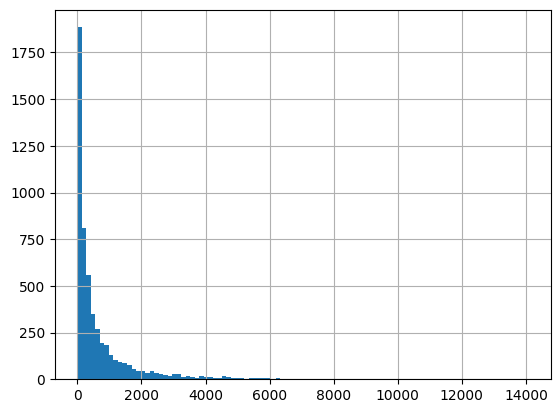

In [21]:
df.vote_count.hist(bins=100)

## Ερώτημα 2

<Axes: ylabel='Frequency'>

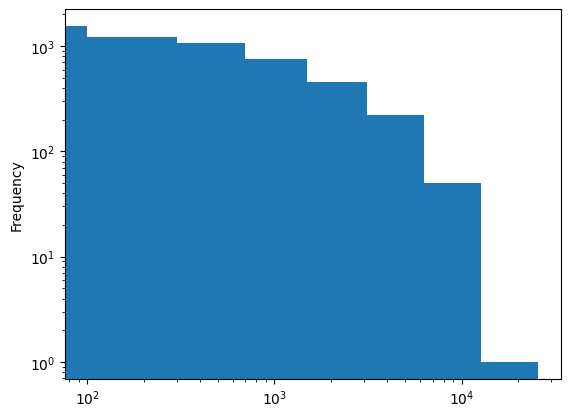

In [22]:
bins = [0]
bin_size = 100
max_value = df['vote_count'].max()

while bins[-1] < max_value:
    bins.append(bins[-1] + bin_size)
    bin_size = bin_size*2

df['vote_count'].plot(kind = 'hist',bins=bins,loglog=True)

## Ερώτημα 3

Τρέχοντας τον παρακάτω κώδικα, θα έχουμε ως index το πλήθος των votes (votes_count) και ως column το πλήθος των γραμμών που έχουν τόσα votes.

In [23]:
vote_count_groups = df.groupby("vote_count").size()

In [24]:
vote_count_groups.head()

,0
vote_count,
0.0,5
1.0,17
2.0,19
3.0,23
4.0,20


Παρακάτω αλλάζουμε το index και κάνουμε sort με βάση τα votes.

In [25]:
vote_count_groups= vote_count_groups.reset_index(name='num_of_records')
vote_count_groups = vote_count_groups.sort_values('vote_count',ascending=False)

In [26]:
vote_count_groups.head()

,vote_count,num_of_records
1777,14075.0,1
1776,12269.0,1
1775,12114.0,1
1774,12000.0,1
1773,11444.0,1


Υπολογίζουμε την τιμή του cumulative frequency για κάθε row

In [27]:
vote_count_groups['cumf'] = vote_count_groups['num_of_records'].cumsum()

In [28]:
vote_count_groups.tail()

,vote_count,num_of_records,cumf
4,4.0,20,5294
3,3.0,23,5317
2,2.0,19,5336
1,1.0,17,5353
0,0.0,5,5358


<Axes: xlabel='vote_count'>

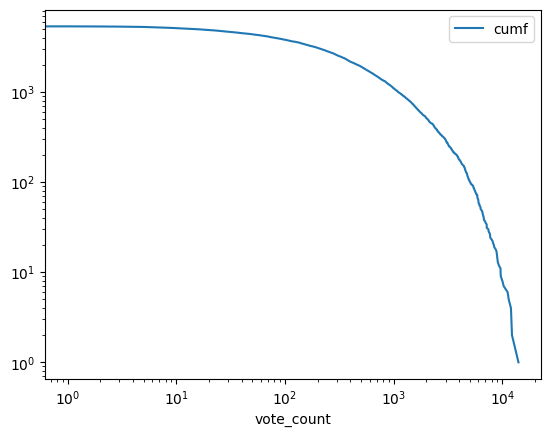

In [29]:
vote_count_groups.plot(x= 'vote_count',y='cumf',loglog=True)

## Ερώτημα 4

In [30]:
import numpy as np
import matplotlib.pyplot as plt

ranks = np.arange(1,len(vote_count_groups)+1)


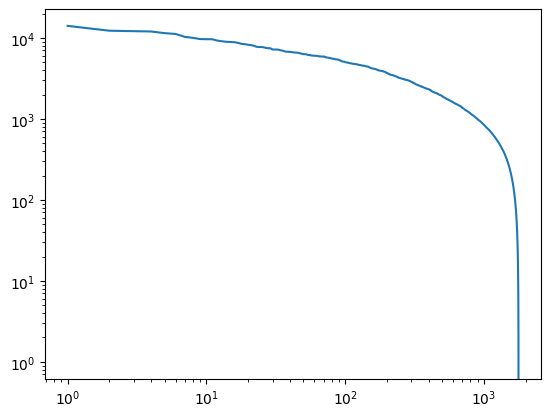

In [31]:
plt.loglog(ranks,vote_count_groups['vote_count'])

## Ερώτημα 5

In [32]:
vote_count_groups['log_votes'] = np.log1p(vote_count_groups['vote_count']+ 0.0001)

In [33]:
vote_count_groups

,vote_count,num_of_records,cumf,log_votes
1777,14075.0,1,1,9.552227
1776,12269.0,1,2,9.414913
1775,12114.0,1,3,9.402200
1774,12000.0,1,4,9.392745
1773,11444.0,1,5,9.345308
...,...,...,...,...
4,4.0,20,5294,1.609458
3,3.0,23,5317,1.386319
2,2.0,19,5336,1.098646
1,1.0,17,5353,0.693197


<Axes: >

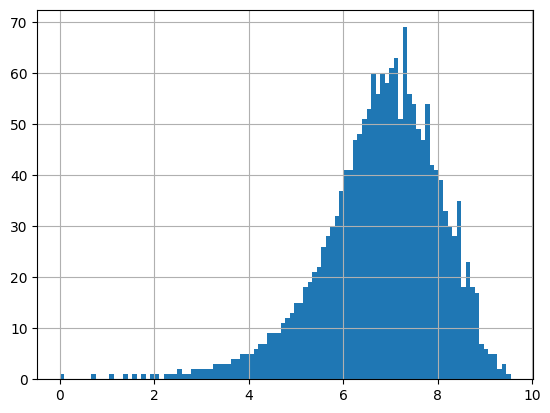

In [34]:
vote_count_groups.log_votes.hist(bins=100)

Text(0.5, 1.0, 'hist of log_votes')

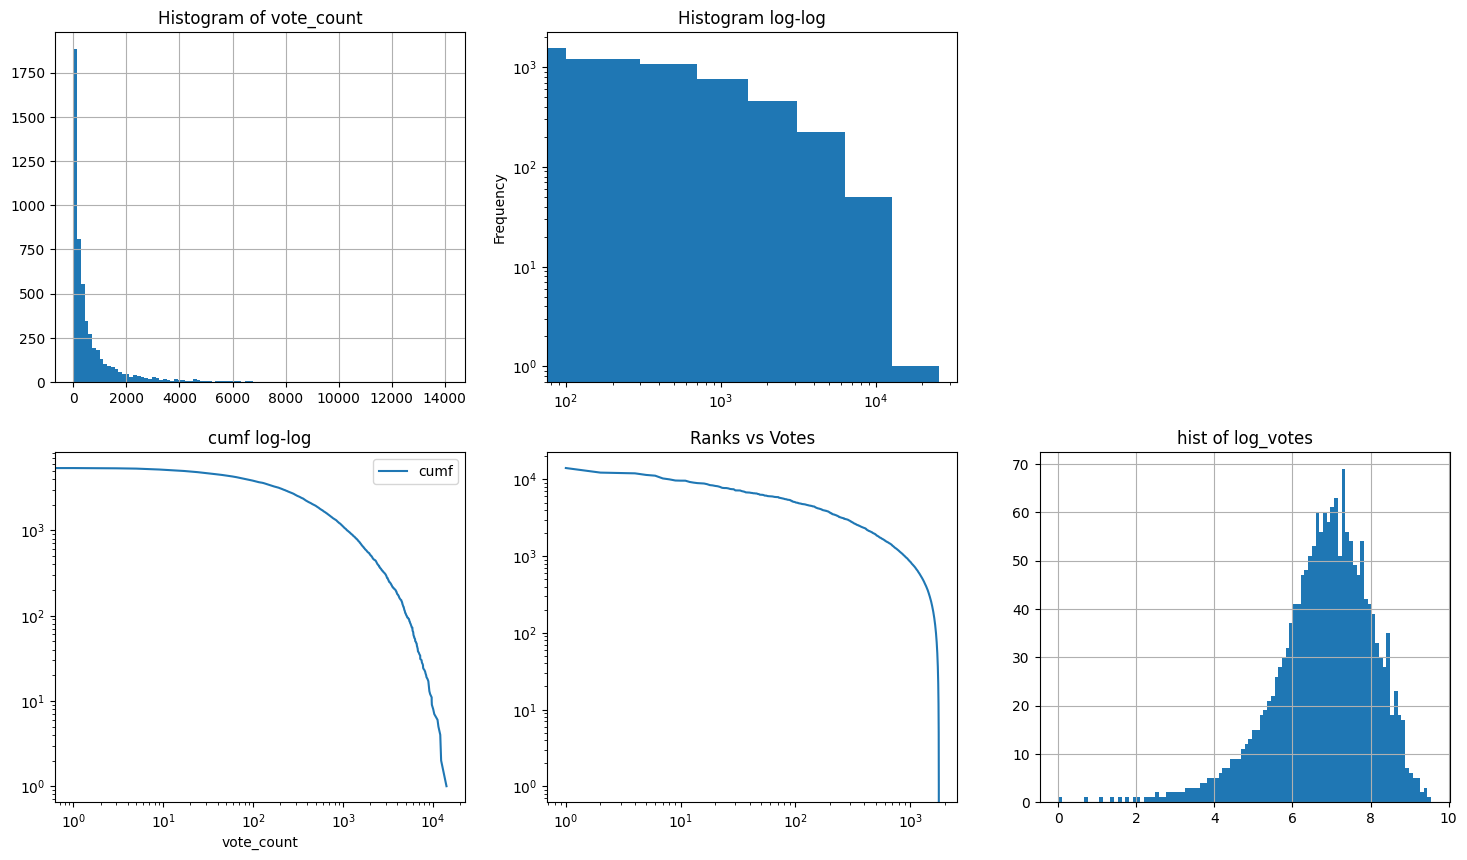

In [35]:
fig, axes = plt.subplots(2,3,figsize=(18,10))
#q1
df.vote_count.hist(bins=100, ax=axes[0,0])
axes[0,0].set_title("Histogram of vote_count")
#q2
df['vote_count'].plot(kind = 'hist',bins=bins,loglog=True, ax=axes[0,1])
axes[0,1].set_title("Histogram log-log")

#q3
vote_count_groups.plot(x= 'vote_count',y='cumf',loglog=True, ax=axes[1,0])
axes[1,0].set_title("cumf log-log")

axes[0,2].set_visible(False)

#q4
axes[1,1].loglog(ranks,vote_count_groups['vote_count'])
axes[1,1].set_title("Ranks vs Votes")

#q5
vote_count_groups.log_votes.hist(bins=100, ax = axes[1,2])
axes[1,2].set_title("hist of log_votes")


Μελετώντας τα γραφήματα που δημιουργήσαμε, μπορούμε να εξάγουμε πολύ ενδιαφέρουσες πληροφορίες. Αρχικά, από το πρώτο γράφημα, βλέπουμε πως η κατανομή των votes είναι πολύ skewed, δηλαδή πολλές ταινίες έχουμε πολύ λίγα votes ενώ λίγες είναι οι ταινίες που συγκετρώνουν πολλά votes και σε καμία περίπτωση δεν ακολουθεί την κανονική κατανομή.  
Από τα γραφήματα log-log παρατηρούμε πως δεν έχουμε κάποια γραμμική πτώση αλλά εμφανίζει μία καμπυλότητα. Στο **Zipf γράφημα** παρατηρούμε πως και εκεί έχουμε μία καμπύλη άρα αντιλαμβανόμαστε από όλα αυτά πως δεν πρόκειται για **power law** κατανομή.  
Στο τελευταίο γράφημα όπου έχουμε πλέον τον λογάριθμο του πλήθους των votes μπορούμε να παρατηρήσουμε πως πλέον η κατανομή είναι περισσότερο σαν κανονική κατανομή.  
Όπως συζητήσαμε και στην θεωρία, από αυτό συμπεραίνουμε πως η κατανομή που ακολουθεί το πλήθος των votes είναι η **log normal**.

# Βήμα 3

In [36]:
df

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,31357,Waiting to Exhale,34.0,127.0,6.1,81452156.0,16000000,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
3,949,Heat,1886.0,170.0,7.7,187436818.0,60000000,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
4,9091,Sudden Death,174.0,106.0,5.5,64350171.0,35000000,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
...,...,...,...,...,...,...,...,...,...
5353,395834,Wind River,181.0,111.0,7.4,184770205.0,11000000,2017-08-03,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
5354,24049,Sivaji: The Boss,25.0,185.0,6.9,19000000.0,12000000,2007-06-14,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam..."
5355,62757,Savages,6.0,100.0,5.8,1328612.0,800000,2006-11-23,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
5356,63281,Pro Lyuboff,3.0,107.0,4.0,1268793.0,2000000,2010-09-30,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ..."


In [37]:
q3 = df[['vote_average','runtime','budget','revenue','vote_count']]
q3 = q3[(q3.vote_count>10)&(q3.runtime>30)&(q3.budget>20000)&(q3.revenue>20000)]

In [38]:
q3

,vote_average,runtime,budget,revenue,vote_count
0,7.7,81.0,30000000,373554033.0,5415.0
1,6.9,104.0,65000000,262797249.0,2413.0
2,6.1,127.0,16000000,81452156.0,34.0
3,7.7,170.0,60000000,187436818.0,1886.0
4,5.5,106.0,35000000,64350171.0,174.0
...,...,...,...,...,...
5346,6.2,149.0,260000000,604942143.0,1440.0
5351,5.7,95.0,60000000,71000000.0,688.0
5352,5.8,86.0,50000000,66913939.0,327.0
5353,7.4,111.0,11000000,184770205.0,181.0


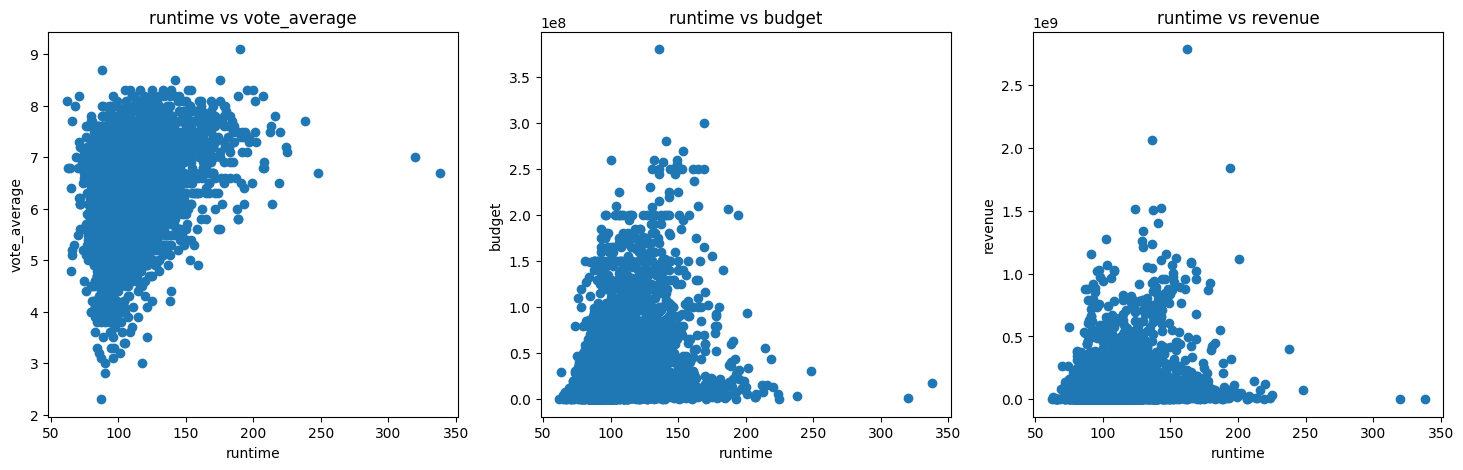

In [39]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].scatter(q3['runtime'],q3['vote_average'])
axes[0].set_title("runtime vs vote_average")
axes[0].set_xlabel("runtime")
axes[0].set_ylabel("vote_average")

axes[1].scatter(q3['runtime'],q3['budget'])
axes[1].set_title("runtime vs budget")
axes[1].set_xlabel("runtime")
axes[1].set_ylabel("budget")

axes[2].scatter(q3['runtime'],q3['revenue'])
axes[2].set_title("runtime vs revenue")
axes[2].set_xlabel("runtime")
axes[2].set_ylabel("revenue")

plt.show()


Κοιτώντας προσεκτικά τα τρία γραφήματα παρατηρούμε πως στα δύο τελευταία γραφήματα οι περισσότερες ταινίες είναι συγκεντρωμένες κάτω αριστερά. Οπτικά δεν φαίνεται να παρουσιάζεται κάποια σημαντική τάση.
Στο πρώτο γράφημα παρατηρούμε πως οι περισσότερες ταινίες είναι συγκεντρωμένες αριστερά με runtime γύρω στο 100 και vote average τα περισσότερα μεταξύ 5 και 8. Εδώ ίσως να μπορεί να παρατηρηθεί μία ασθενής τάση.  
Παρακάτω θα πραγματοποιήσουμε και τα στατιστικά τεστ.

In [40]:
from  scipy import stats

columns = ['vote_average','budget','revenue']

for col in columns:
    pcc, pv = stats.pearsonr(q3['runtime'],q3[col])
    print(f"runtime versus {col} :")
    print(f"pearson corr pcc = {pcc:.4f}")
    print(f"p value pv = {pv:.4e}")
    print("-------------------------------------------")

runtime versus vote_average :
pearson corr pcc = 0.3573
p value pv = 2.8069e-150
-------------------------------------------
runtime versus budget :
pearson corr pcc = 0.1930
p value pv = 4.2734e-43
-------------------------------------------
runtime versus revenue :
pearson corr pcc = 0.1927
p value pv = 5.3319e-43
-------------------------------------------


Πραγματοποιώντας και τα στατιστικά τεστ αυτό που παρατηρούμε είναι πως σύμφωνα με το p-value και στις τρεις περιπτώσεις έχουμε κάποια συσχέτιση.
Δεδομένου όμως ότι η τιμή του pearson correlation είναι σχετικά μικρή (~0.2 και ~0.35) δεν μπορούμε να πούμε πως είναι και ισχυρή. Φυσικά η συσχέτιση μεταξύ του runtime και του vote_average είναι η πιο ισχυρή.

# Βήμα 4

In [41]:
df

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,31357,Waiting to Exhale,34.0,127.0,6.1,81452156.0,16000000,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
3,949,Heat,1886.0,170.0,7.7,187436818.0,60000000,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
4,9091,Sudden Death,174.0,106.0,5.5,64350171.0,35000000,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
...,...,...,...,...,...,...,...,...,...
5353,395834,Wind River,181.0,111.0,7.4,184770205.0,11000000,2017-08-03,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
5354,24049,Sivaji: The Boss,25.0,185.0,6.9,19000000.0,12000000,2007-06-14,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam..."
5355,62757,Savages,6.0,100.0,5.8,1328612.0,800000,2006-11-23,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
5356,63281,Pro Lyuboff,3.0,107.0,4.0,1268793.0,2000000,2010-09-30,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ..."


In [42]:
df.release_date.describe()

,release_date
count,5358
mean,2000-04-12 15:01:24.658454656
min,1915-02-08 00:00:00
25%,1994-07-01 00:00:00
50%,2004-11-09 12:00:00
75%,2011-04-08 00:00:00
max,2017-08-04 00:00:00


Το πρώτο που θα κάνουμε είναι να δημιουργήσουμε ένα καινούργιο πεδίο το οποίο θα έχει την δεκαετία στην οποία ανήκει η ταινία. Αφού γίνει αυτό, μετά θα κάνουμε group τις ταινίες με βάση την δεκαετία τους.

In [43]:
df_q4 = df[df['vote_count']>=10].copy()

Θα κάνουμε ακέραια διαίρεση (δηλαδή σαν να αφαιρούμε το τελευταίο ψηφίο από κάθε έτος) και θα πολλαπλασιάζουμε με το 10 για να προσθέσουμε το 0

In [44]:
df_q4['decade'] = df_q4['release_date'].apply(lambda x : (x.year // 10)*10)

Σε αυτό το σημείο κάνουμε groupby ανά δεκαετία και έπειτα κάνουμε aggregatation με το size. Έτσι, το decade_count θα έχει το πλήθος ταινιών ανά δεκαετία. Στη συνέχεια, στο valid_decades φιλτράρουμε τις δεκαετίες με περισσότερες από 50 ταινίες.

In [45]:
decade_count = df_q4.groupby('decade')
decade_count = decade_count.size()
valid_decades = decade_count[decade_count >= 50].index
df_q4 = df_q4[df_q4['decade'].isin(valid_decades)]

In [46]:
df_q4

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres,decade
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",1990
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",1990
2,31357,Waiting to Exhale,34.0,127.0,6.1,81452156.0,16000000,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",1990
3,949,Heat,1886.0,170.0,7.7,187436818.0,60000000,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",1990
4,9091,Sudden Death,174.0,106.0,5.5,64350171.0,35000000,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",1990
...,...,...,...,...,...,...,...,...,...,...
5350,26147,FC Venus,10.0,107.0,5.6,2411594.0,2196531,2005-12-30,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",2000
5351,353491,The Dark Tower,688.0,95.0,5.7,71000000.0,60000000,2017-08-03,"[{'id': 28, 'name': 'Action'}, {'id': 37, 'nam...",2010
5352,378236,The Emoji Movie,327.0,86.0,5.8,66913939.0,50000000,2017-07-28,"[{'id': 35, 'name': 'Comedy'}, {'id': 10751, '...",2010
5353,395834,Wind River,181.0,111.0,7.4,184770205.0,11000000,2017-08-03,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",2010


<Axes: xlabel='decade', ylabel='vote_average'>

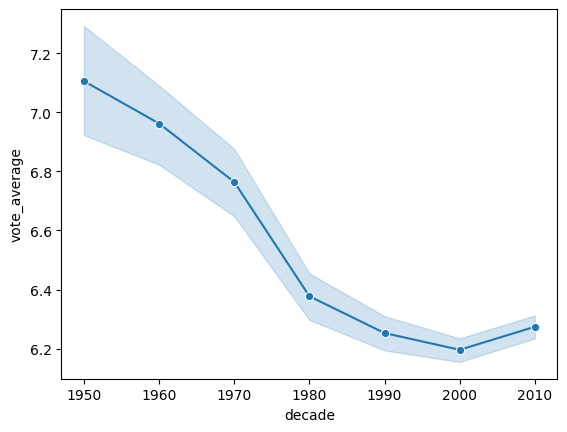

In [47]:
import seaborn as sns
sns.lineplot(data = df_q4,x='decade',y='vote_average',errorbar=('ci',95),marker='o')

Δημιουργώντας το παραπάνω γράφημα φαίνεται πως όσο πιο καινούργια (από πιο πρόσφατη δεκαετία) είναι μία ταινία, τόσο πιο χαμηλό μέσο όρο βαθμολογιών έχει με μία σταθεροποίηση στις τελευταίες δεκαετίες.  
Ενδιαφέρον παρουσιάζει και το error bar, όπου μπορούμε να παρατηρήσουμε πως στις πιο παλιές δεκαετίες είναι πιο πλατύ, ενώ στις πιο πρόσφατες δεκαετίες πιο στενό.  
Όπως γνωρίζουμε το error bar εκφράζει την αβεβαιότητα, οπότε αυτό μπορεί να οφείλεται είτε γιατί παλαιότερα έχουμε λιγότερες ταινίες σε σχέση με πιο πρόσφατες δεκαετίες είτε επειδή στις πιο παλιές ταινίες έχουμε μεγαλύτερη διακύμανση στο vote_average.

## Bonus

Μία εναλλακτική που μπορούμε να προτείνουμε είναι να εφαρμόσουμε sampling προκειμένου να καταφέρουμε να εξαλείψουμε την διαφορά που υπάρχει ανάμεσα στο πλήθος των ταινιών ανά δεκαετία.  
Έτσι θα εφαρμόσουμε τον αλγόριθμο του sampling που μάθαμε στο μάθημα.

In [48]:
df_q4b = df[df['vote_count']>=10].copy()

In [49]:
df_q4b['decade'] = df_q4b['release_date'].apply(lambda x : (x.year // 10)*10)

In [50]:
decade_count = df_q4b.groupby('decade')
decade_count = decade_count.size()

In [51]:
decade_count

,0
decade,
1910,2
1920,10
1930,31
1940,37
1950,69
1960,127
1970,181
1980,498
1990,891


Στο παρακάτω κελί κώδικα φαίνεται ο αλγόριθμος reservoir sampling που εφαρμόζουμε

In [52]:
import random

def reservoir_sample_rows(rows, K):
    reservoir = []
    counter = 0

    for idx, row in rows.iterrows():
        if counter < K:
            reservoir.append(row)
        else:
            randIndex = random.randint(0, counter)
            if randIndex < K:
                reservoir[randIndex] = row
        counter += 1

    return pd.DataFrame(reservoir)

Πάλι θα φιλτράρουμε τις δεκαετίες ώστε να έχουν περισσότερες από 50 ταινίες και θα πάρουμε ως αριθμό δειγμάτων τον ελάχιστο αριθμό ταινιών στις δεκαετίες που έμειναν

In [53]:
valid_decades = decade_count[decade_count >= 50].index
df_q4b = df_q4b[df_q4b['decade'].isin(valid_decades)]

In [129]:
K = 69   #sample size

sampled_list = []

for decade, group in df_q4b.groupby("decade"):
    if len(group) >= K:
        sampled = reservoir_sample_rows(group, K)
        sampled_list.append(sampled)

df_sampled = pd.concat(sampled_list)

<Axes: xlabel='decade', ylabel='vote_average'>

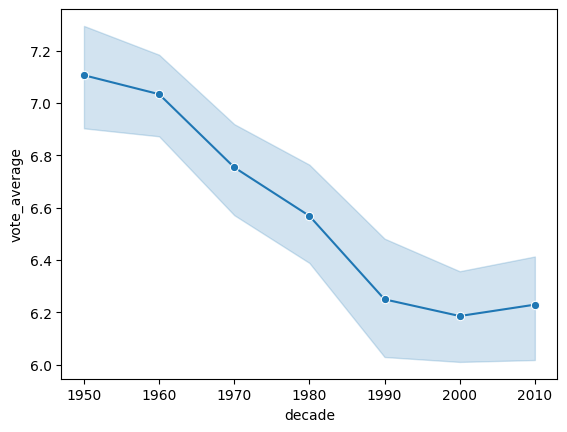

In [130]:
sns.lineplot( x="decade", y="vote_average", data=df_sampled, errorbar=('ci', 95),marker='o')

Αν τρέξουμε πολλές φορές τον κώδικα βλέπουμε ότι κάθε φορά τα τυχαία δείγματα που έχουν επιλεγεί, έχουν παρόμοια συμπεριφορά με την αρχή του βήματος 4. Δηλαδή φαίνεται ότι ο κόσμος προτιμάει λίγο περισσότερο τις παλαιότερες ταινίες.

# Βήμα 5

In [56]:
df

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,31357,Waiting to Exhale,34.0,127.0,6.1,81452156.0,16000000,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
3,949,Heat,1886.0,170.0,7.7,187436818.0,60000000,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
4,9091,Sudden Death,174.0,106.0,5.5,64350171.0,35000000,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
...,...,...,...,...,...,...,...,...,...
5353,395834,Wind River,181.0,111.0,7.4,184770205.0,11000000,2017-08-03,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
5354,24049,Sivaji: The Boss,25.0,185.0,6.9,19000000.0,12000000,2007-06-14,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam..."
5355,62757,Savages,6.0,100.0,5.8,1328612.0,800000,2006-11-23,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam..."
5356,63281,Pro Lyuboff,3.0,107.0,4.0,1268793.0,2000000,2010-09-30,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ..."


In [57]:
df_exploded= df.explode('genres')

In [58]:
df_exploded

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"{'id': 16, 'name': 'Animation'}"
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"{'id': 35, 'name': 'Comedy'}"
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"{'id': 10751, 'name': 'Family'}"
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"{'id': 12, 'name': 'Adventure'}"
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"{'id': 14, 'name': 'Fantasy'}"
...,...,...,...,...,...,...,...,...,...
5356,63281,Pro Lyuboff,3.0,107.0,4.0,1268793.0,2000000,2010-09-30,"{'id': 18, 'name': 'Drama'}"
5357,63898,Antidur,1.0,91.0,1.0,1413000.0,5000000,2007-09-06,"{'id': 28, 'name': 'Action'}"
5357,63898,Antidur,1.0,91.0,1.0,1413000.0,5000000,2007-09-06,"{'id': 35, 'name': 'Comedy'}"
5357,63898,Antidur,1.0,91.0,1.0,1413000.0,5000000,2007-09-06,"{'id': 80, 'name': 'Crime'}"


In [59]:
df_exploded['genre_id'] = df_exploded['genres'].apply(lambda x: x['id'])
df_exploded['genre_name'] = df_exploded['genres'].apply(lambda x: x['name'])

In [60]:
df_exploded

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres,genre_id,genre_name
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"{'id': 16, 'name': 'Animation'}",16,Animation
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"{'id': 35, 'name': 'Comedy'}",35,Comedy
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"{'id': 10751, 'name': 'Family'}",10751,Family
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"{'id': 12, 'name': 'Adventure'}",12,Adventure
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"{'id': 14, 'name': 'Fantasy'}",14,Fantasy
...,...,...,...,...,...,...,...,...,...,...,...
5356,63281,Pro Lyuboff,3.0,107.0,4.0,1268793.0,2000000,2010-09-30,"{'id': 18, 'name': 'Drama'}",18,Drama
5357,63898,Antidur,1.0,91.0,1.0,1413000.0,5000000,2007-09-06,"{'id': 28, 'name': 'Action'}",28,Action
5357,63898,Antidur,1.0,91.0,1.0,1413000.0,5000000,2007-09-06,"{'id': 35, 'name': 'Comedy'}",35,Comedy
5357,63898,Antidur,1.0,91.0,1.0,1413000.0,5000000,2007-09-06,"{'id': 80, 'name': 'Crime'}",80,Crime


In [61]:
total_movies_per_genre = df_exploded['genre_name'].value_counts()

In [62]:
total_movies_per_genre

,count
genre_name,
Drama,2583
Comedy,1846
Thriller,1503
Action,1413
Romance,1013
Adventure,960
Crime,860
Science Fiction,633
Horror,586


Πρέπει να κρατήσουμε τις ταινίες τα genres των οποίων εμφανίζονται σε παραπάνω από 100 ταινίες

In [63]:
df_exploded =  df_exploded[df_exploded['genre_name'].isin(total_movies_per_genre[total_movies_per_genre>=100].index)]

In [64]:
df_exploded_stats = df_exploded.groupby('genre_name').agg(total_movies=('id','size'),total_votes=('vote_count','sum'),avg_runtime=('runtime','mean'),vote_average=('vote_average','mean'),
                                                    total_revenue=('revenue','sum'),avg_revenue=('revenue','mean'),total_budget=('budget','sum'),avg_budget=('budget','mean'))


Παρακάτω, όπως ζητείται παραθέτουμε κάποια πολύ ενδιαφέροντα στατιστικά ανά είδος ταινίας.

In [65]:
df_exploded_stats

,total_movies,total_votes,avg_runtime,vote_average,total_revenue,avg_revenue,total_budget,avg_budget
genre_name,,,,,,,,
Action,1413,1534087.0,113.054494,6.105379,1.966185e+11,1.391497e+08,70325900682,4.977063e+07
Adventure,960,1330656.0,113.012500,6.249687,1.963006e+11,2.044798e+08,61201562778,6.375163e+07
Animation,293,364811.0,90.344710,6.477474,6.553552e+10,2.236707e+08,18604727833,6.349736e+07
Comedy,1846,1057953.0,102.685265,6.090791,1.546027e+11,8.375013e+07,52302193647,2.833272e+07
Crime,860,635422.0,111.210465,6.390581,6.023665e+10,7.004261e+07,24117452350,2.804355e+07
Drama,2583,1463858.0,116.061556,6.520674,1.497653e+11,5.798115e+07,57857418453,2.239931e+07
Family,532,568586.0,98.225564,6.187406,1.037537e+11,1.950257e+08,30776405305,5.785039e+07
Fantasy,511,686040.0,107.661448,6.170841,1.015550e+11,1.987378e+08,31631238814,6.190066e+07
History,235,120146.0,138.306383,6.797447,1.455401e+10,6.193195e+07,7061803497,3.005023e+07


In [66]:
df_credits = pd.read_csv("credits.csv")
df_credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [67]:
print("type for cast is ",type(df_credits.loc[0, 'cast']))
print("type for crew is ",type(df_credits.loc[0, 'crew']))


type for cast is  <class 'str'>
type for crew is  <class 'str'>


Τα πεδία crew και cast είναι string που περιέχουν λίστα dictionaries. Τα μετατρέπουμε σε list για να μπορέσουμε να κάνουμε explode.

In [68]:
import ast
df_credits['cast'] = df_credits['cast'].apply(ast.literal_eval)
df_credits['crew'] = df_credits['crew'].apply(ast.literal_eval)

In [69]:
df_credits = df_credits.explode('crew')

In [70]:
df_credits

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f49', 'dep...",862
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f4f', 'dep...",862
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f55', 'dep...",862
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f5b', 'dep...",862
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f61', 'dep...",862
...,...,...,...
45473,"[{'cast_id': 6, 'character': 'Emily Shaw', 'cr...","{'credit_id': '52fe4776c3a368484e0c8399', 'dep...",67758
45473,"[{'cast_id': 6, 'character': 'Emily Shaw', 'cr...","{'credit_id': '52fe4776c3a368484e0c839f', 'dep...",67758
45474,"[{'cast_id': 2, 'character': '', 'credit_id': ...","{'credit_id': '533bccebc3a36844cf0011a7', 'dep...",227506
45474,"[{'cast_id': 2, 'character': '', 'credit_id': ...","{'credit_id': '58ebbc26925141281908aa0a', 'dep...",227506


In [71]:
df_credits = df_credits[df_credits['crew'].notna()].copy()
df_credits['position'] = df_credits['crew'].apply(lambda x: x['job'])

In [72]:
df_credits['gender'] = df_credits['crew'].apply(lambda x: x['gender'])

In [73]:
df_credits

,cast,crew,id,position,gender
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f49', 'dep...",862,Director,2
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f4f', 'dep...",862,Screenplay,2
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f55', 'dep...",862,Screenplay,2
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f5b', 'dep...",862,Screenplay,2
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","{'credit_id': '52fe4284c3a36847f8024f61', 'dep...",862,Screenplay,0
...,...,...,...,...,...
45473,"[{'cast_id': 6, 'character': 'Emily Shaw', 'cr...","{'credit_id': '52fe4776c3a368484e0c8399', 'dep...",67758,Original Music Composer,0
45473,"[{'cast_id': 6, 'character': 'Emily Shaw', 'cr...","{'credit_id': '52fe4776c3a368484e0c839f', 'dep...",67758,Director of Photography,2
45474,"[{'cast_id': 2, 'character': '', 'credit_id': ...","{'credit_id': '533bccebc3a36844cf0011a7', 'dep...",227506,Director,0
45474,"[{'cast_id': 2, 'character': '', 'credit_id': ...","{'credit_id': '58ebbc26925141281908aa0a', 'dep...",227506,Producer,2


In [74]:
df_credits = df_credits[(df_credits.position == 'Director')&(df_credits.gender !=0)]

Εδώ μπορούμε να αλλάξουμε τα id των gender σε male και female για την καλύτερη παρουσίαση των δεδομένων

In [75]:
def gender_mod(row):
  if (row.gender == 1):
    return 'female'
  else:
    return 'male'

df_credits['gender'] = df_credits.apply(gender_mod, axis=1)

/tmp/ipython-input-917561298.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_credits['gender'] = df_credits.apply(gender_mod, axis=1)


In [76]:
df_credits = df_credits.reset_index(drop=True)

In [77]:
df_credits['gender'].describe()

,gender
count,29478
unique,2
top,male
freq,27581


In [78]:
df_genderStats = df_credits.groupby('gender').agg(total_movies=('id','count'))

In [79]:
df_genderStats = df_genderStats.reset_index()

In [80]:
df_genderStats

,gender,total_movies
0,female,1897
1,male,27581


Στο παραπάνω είναι ξεκάθαρη η κυριαρχία του ανδρικού φύλου στην θέση του Director

Στη συνέχεια, κάνουμε merge τα dataframes με τα genres (df_exploded)  και τα φύλλα (df_credits) στο κοινό τους πεδίο id και φτιάχνουμε το contigency table

In [81]:
#df_exploded, df_credits
df_credits = df_credits.drop(columns = ['cast','crew'])
df_exploded = df_exploded.drop(columns = 'genres')
merged_df = pd.merge(df_exploded, df_credits,on='id')
merged_df.head()

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genre_id,genre_name,position,gender
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,16,Animation,Director,male
1,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,35,Comedy,Director,male
2,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,10751,Family,Director,male
3,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,12,Adventure,Director,male
4,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,14,Fantasy,Director,male


In [82]:
contigency = pd.crosstab(merged_df['genre_name'],merged_df['gender'])
#contigency

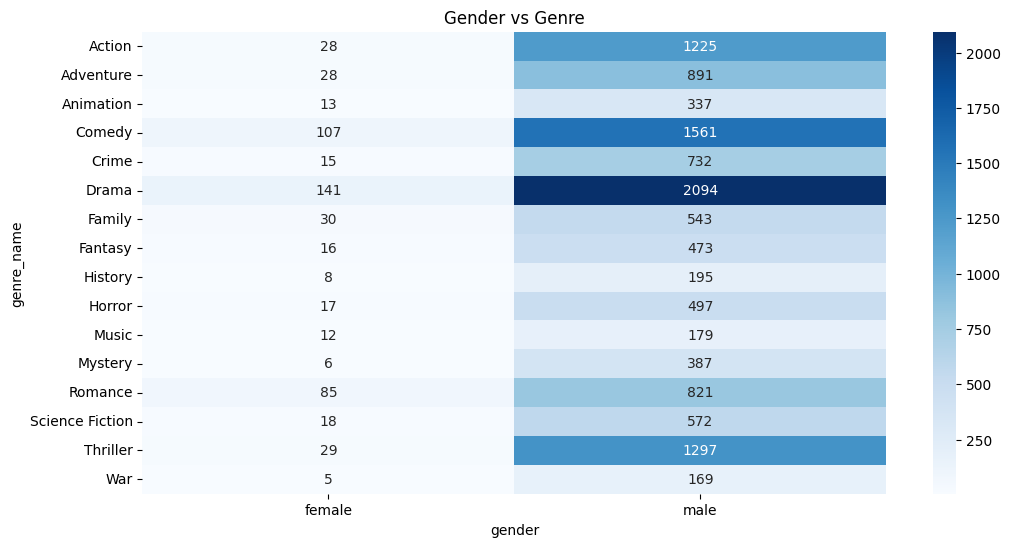

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(contigency,annot=True,fmt='d',cmap='Blues')
plt.title("Gender vs Genre")
plt.show()

In [84]:
from scipy.stats import chi2_contingency

chi2, pv, dof, expected = chi2_contingency(contigency)
print("p-value is",pv)

p-value is 6.240871238028259e-24


Εδώ βλέπουμε ότι το p-value είναι πολύ μικρότερο από 0.05. Αυτό υποδεικνύει ότι υπάρχει συσχέτιση μεταξύ του φύλου και του τύπου ταινίας.

In [85]:
lift = contigency/expected
lift_df = pd.DataFrame(lift,index=contigency.index,columns=contigency.columns)
lift_df

gender,female,male
genre_name,,
Action,0.501832,1.023217
Adventure,0.684217,1.014717
Animation,0.834117,1.007731
Comedy,1.440586,0.979467
Crime,0.450944,1.025589
Drama,1.416750,0.980577
Family,1.175759,0.991809
Fantasy,0.734789,1.012360
History,0.885005,1.005359


In [86]:
lift_fulltable = lift_df.stack().reset_index()
lift_fulltable.columns = ['genre','gender','lift_value']

highest = lift_fulltable.sort_values('lift_value',ascending=False)
lowest = lift_fulltable.sort_values('lift_value',ascending=True)

In [87]:
print("Highest lift")
highest.head()

Highest lift


,genre,gender,lift_value
24,Romance,female,2.106892
6,Comedy,female,1.440586
10,Drama,female,1.416750
20,Music,female,1.410910
12,Family,female,1.175759


In [88]:
print("Lowest lift")
lowest.head()

Lowest lift


,genre,gender,lift_value
22,Mystery,female,0.342855
8,Crime,female,0.450944
28,Thriller,female,0.491141
0,Action,female,0.501832
30,War,female,0.645316


Μελετώντας τα παραπάνω δεδομένα, το συμπέρασμα που μπορούμε να εξάγουμε είναι ότι σε ταινίες που ανήκουν στα είδη Romance, Comedy, Drama και Music, οι άντρες εμφανίζονται ως Directors πολύ περισσότερο από όσο αναμέναμε (αφού lift_value >1).  
Αντίθετα, σε ταινίες που ανήκουν στα είδη Mystery, Crime, Thriller Action και War, οι γυναίκες εμφανίζονται πολύ λιγότερο από όσο αναμέναμε.

# Βήμα 6

In [89]:
df_q6 = df_exploded[(df_exploded.genre_name == 'Action') | (df_exploded.genre_name == 'Drama')]
df_q6 = df_q6[['vote_average','revenue','budget','genre_name']]

In [90]:
df_q6= df_q6.reset_index()

In [91]:
df_q6

,index,vote_average,revenue,budget,genre_name
0,2,6.1,81452156.0,16000000,Drama
1,3,7.7,187436818.0,60000000,Action
2,3,7.7,187436818.0,60000000,Drama
3,4,5.5,64350171.0,35000000,Action
4,5,6.6,352194034.0,58000000,Action
...,...,...,...,...,...
3991,5354,6.9,19000000.0,12000000,Action
3992,5354,6.9,19000000.0,12000000,Drama
3993,5355,5.8,1328612.0,800000,Drama
3994,5356,4.0,1268793.0,2000000,Drama


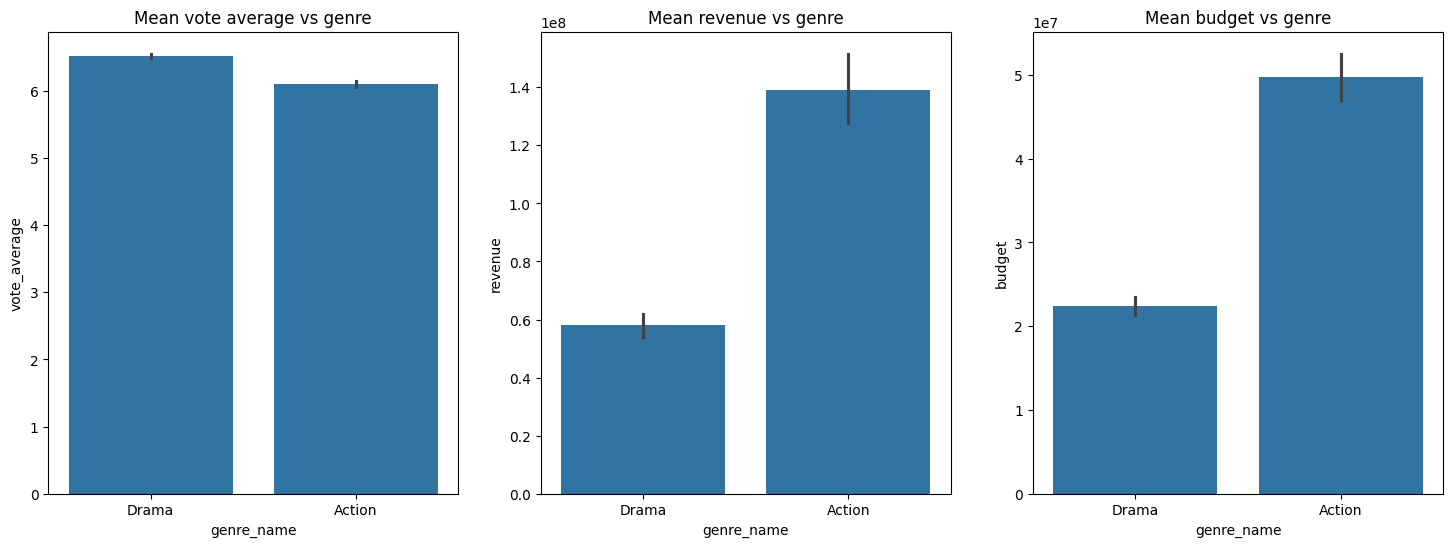

In [92]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.barplot(data=df_q6, x='genre_name',y='vote_average',errorbar=('ci', 95))
plt.title("Mean vote average vs genre")

plt.subplot(1,3,2)
sns.barplot(data=df_q6,x='genre_name',y='revenue',errorbar=('ci', 95))
plt.title("Mean revenue vs genre")

plt.subplot(1,3,3)
sns.barplot(data=df_q6,x='genre_name',y='budget',errorbar=('ci', 95))
plt.title("Mean budget vs genre")


plt.show()


Από τα παραπάνω γραφήματα προκύπτουν κάποια ενδιαφέροντα συμπεράσματα. Αρχικά, παρατηρούμε πως η μέση τιμή του vote average και στα δύο είδη ταινιών έχει μικρή διαφορά, ελάχιστα μεγαλύτερη στις δραματικές ταινίες, ωστόσο μπορούμε να πούμε πως αρέσουν περίπου το ίδιο.  
Στο δίπλα γράφημα, με το μέσο revenue, μπορούμε να δούμε πως οι ταινίες δράσεις κυριαρχούν, έχοντας σχεδόν διπλάσιο revenue σε σχέση με τις δραματικές.  
Ωστόσο, βλέποντας το τελευταίο γράφημα, μπορούμε να δούμε πως και εκεί κυριαρχούν οι ταινίες δράσεις, έχοντας πολύ μεγαλύτερο (περισσότερο από δύο φορές) το μέσο budget των ταινιών με θέμα το δράμα, πράγμα που είναι και λίγο αναμενόμενο λαμβάνοντας υπόψιν τα τεράστια ποσά που πρέπει να δαπανηθούν προκειμένου να είναι εφικτές οι τρομερές σκηνές που προσφέρουν οι ταινίες δράσης.

### Calculating the t-test

In [93]:
action_df = df_q6[df_q6['genre_name'] == 'Action']
drama_df = df_q6[df_q6['genre_name'] == 'Drama']

In [94]:
drama_df

,index,vote_average,revenue,budget,genre_name
0,2,6.1,81452156.0,16000000,Drama
2,3,7.7,187436818.0,60000000,Drama
5,6,6.5,107879496.0,62000000,Drama
6,7,7.1,13681765.0,44000000,Drama
8,9,7.8,116112375.0,52000000,Drama
...,...,...,...,...,...
3985,5344,6.2,56100000.0,8520000,Drama
3988,5347,5.3,11666088.0,2000000,Drama
3992,5354,6.9,19000000.0,12000000,Drama
3993,5355,5.8,1328612.0,800000,Drama


Θα πραγματοποιήσουμε τα παρακάτω στατιστικά τεστ έχοντας ως null hypothesis πως δεν υπάρχουν συσχετίσεις μεταξύ των μέσων τιμών των revenue, budget και vote average μεταξύ των δύο διαφορετικών τύπων ταινιών (Action, Drama).

In [95]:
import scipy

tstat_vote_avg, p_vote_avg = stats.ttest_ind(action_df['vote_average'],drama_df['vote_average'],equal_var=False)
tstat_revenue, p_revenue = stats.ttest_ind(action_df['revenue'],drama_df['revenue'],equal_var=False)
tstat_budget, p_budget = stats.ttest_ind(action_df['budget'],drama_df['budget'],equal_var=False)

print("p-value for vote_avg",p_vote_avg)
print("p-value for revenue",p_revenue)
print("p-value for budget",p_budget)

p-value for vote_avg 2.2675678538967393e-45
p-value for revenue 3.524427492940174e-35
p-value for budget 7.468484723140847e-66


Και στις τρεις περιπτώσεις βλέπουμε το p-value είναι πολύ μικρό (<0.05) οπότε μπορούμε να πούμε με στατιστική σημαντικότητα πως υπάρχει συσχέτιση.

# Βήμα 7

Θα κάνουμε χρήση του dataframe **merged_df** από το βήμα 5. Θα χρειαστεί να κρατήσουμε μόνο μία φορά τις ταινίες που μπορεί να εμφανίζονται αρκετές φορές.

In [96]:
merged_df

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genre_id,genre_name,position,gender
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,16,Animation,Director,male
1,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,35,Comedy,Director,male
2,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,10751,Family,Director,male
3,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,12,Adventure,Director,male
4,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,14,Fantasy,Director,male
...,...,...,...,...,...,...,...,...,...,...,...,...
12526,24049,Sivaji: The Boss,25.0,185.0,6.9,19000000.0,12000000,2007-06-14,28,Action,Director,male
12527,24049,Sivaji: The Boss,25.0,185.0,6.9,19000000.0,12000000,2007-06-14,35,Comedy,Director,male
12528,24049,Sivaji: The Boss,25.0,185.0,6.9,19000000.0,12000000,2007-06-14,18,Drama,Director,male
12529,63281,Pro Lyuboff,3.0,107.0,4.0,1268793.0,2000000,2010-09-30,10749,Romance,Director,female


In [97]:
df_q7 = merged_df.drop_duplicates(subset='id').reset_index(drop=True)
df_q7 = df_q7.drop(columns = ['vote_count','runtime','vote_average','revenue','release_date','genre_id','position'])
df_q7

,id,title,budget,genre_name,gender
0,862,Toy Story,30000000,Animation,male
1,8844,Jumanji,65000000,Adventure,male
2,31357,Waiting to Exhale,16000000,Comedy,male
3,949,Heat,60000000,Action,male
4,9091,Sudden Death,35000000,Action,male
...,...,...,...,...,...
4457,335988,Transformers: The Last Knight,260000000,Action,male
4458,353491,The Dark Tower,60000000,Action,male
4459,395834,Wind River,11000000,Action,male
4460,24049,Sivaji: The Boss,12000000,Action,male


In [98]:
df_q7.describe()

,id,budget
count,4462.000000,4.462000e+03
mean,53038.213581,3.379771e+07
std,88766.364435,4.161221e+07
min,5.000000,1.000000e+00
25%,7527.750000,6.791000e+06
50%,12470.500000,1.900000e+07
75%,49032.750000,4.400000e+07
max,440642.000000,3.800000e+08


Αρχικά θα δημιουργήσουμε δύο dataframes, ένα για κάθε φύλο, και θα ελέγξουμε με γράφημα τις κατανομές που ακολουθούν οι προυπολογισμοί των ταινιών.
Επειδή το εύρος των budget είναι πολύ μεγάλο, θα χρησιμοποίησουμε τον λογάριθμο.

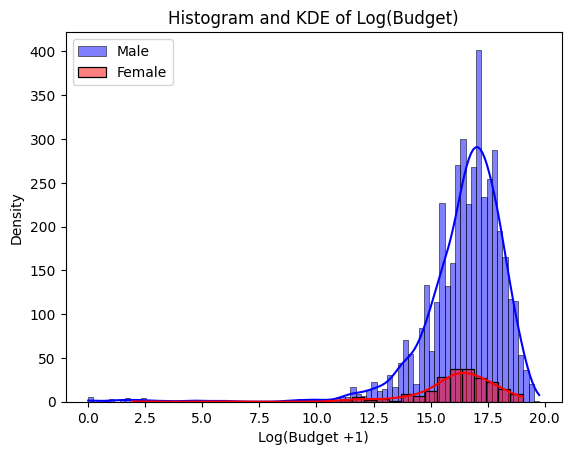

In [99]:
sns.histplot(np.log(df_q7[df_q7['gender']=='male']['budget']),
             label='Male',color='blue',kde=True)
sns.histplot(np.log(df_q7[df_q7['gender']=='female']['budget']),
             label='Female',color='red',kde=True)
plt.title('Histogram and KDE of Log(Budget)')
plt.legend()
plt.xlabel('Log(Budget +1)')
plt.ylabel('Density')

plt.show()

Μελετώντας το παραπάνω ιστόγραμμα, μπορούμε να παρατηρήσουμε πως η κατανομή του budget και για τα δύο φύλα είναι περίπου η ίδια. Φυσικά, αυτό δεν είναι αρκετό και παρακάτω θα συνεχίσουμε την ανάλυσή μας.

Text(0.5, 1.0, 'Violin Plot of Budgets by Gender')

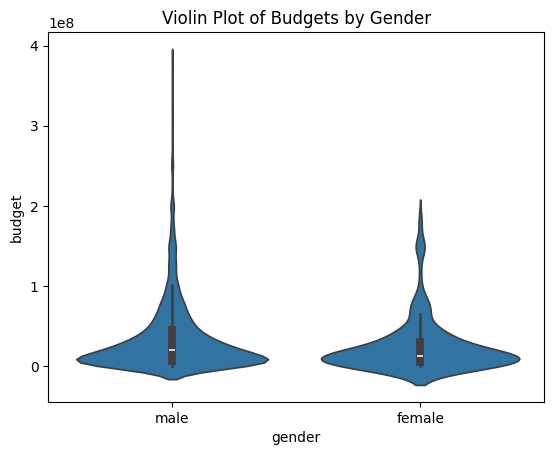

In [100]:
sns.violinplot(data=df_q7, x='gender', y='budget',)
plt.title('Violin Plot of Budgets by Gender')

Στο παραπάνω διάγραμμα αυτό που μπορούμε να παρατηρήσουμε είναι ότι οι κατανομές και εδώ φαίνονται περίπου ίδιες και το "βιολί" των ανδρών σκηνοθετών είναι αρκετά πιο ψηλό και δείχνει ότι υπάρχουν ταινίες με αρκετά μεγαλύτερο budget που σκηνοθετούν αυτοί συγκριτικά με τις γυναίκες.

<Axes: xlabel='gender', ylabel='budget'>

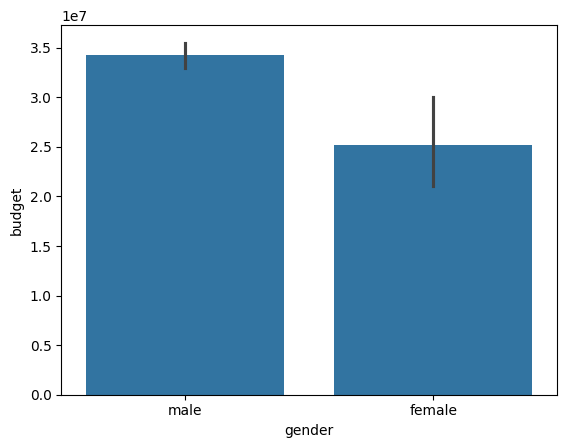

In [101]:
sns.barplot(x='gender',y='budget', data = df_q7, errorbar=('ci', 95))

Text(0.5, 1.0, 'Boxplot of Budgets by Gender')

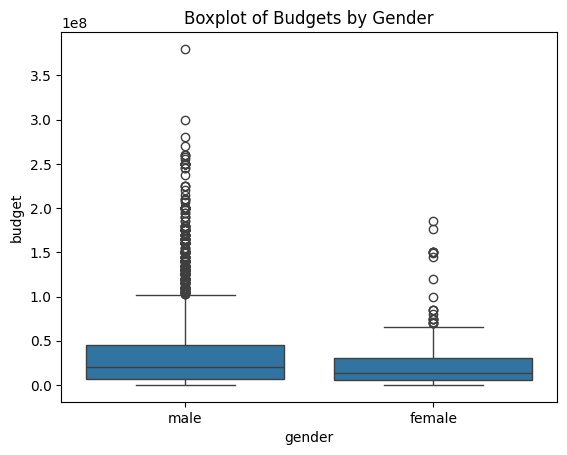

In [102]:
sns.boxplot(data=df_q7, x='gender', y='budget')
plt.title('Boxplot of Budgets by Gender')

Στο παραπάνω boxplot, φαίνεται λίγο πιο ξεκάθαρα πως το μέσο budget των ανδρών σκηνοθετών είναι λίγο μεγαλύτερο από αυτό των γυναικών. Το εύρος budget των ανδρών είναι μεγαλύτερο και επίσης φαίνεται αυτό που είδαμε και στο προηγούμενο plot, οι outliers, οι ταινίες δηλαδή με πολύ υψηλό budget, όπου οι άνδρες σκηνοθετούν περισσότερο.  
Αφού αναλύσαμε τα διαγράμματα, θα περάσουμε τώρα στα στατιστικά τεστ. Το πρώτο τεστ που θα εφαρμόσουμε είναι το t test.  
Έχουμε ως Null Hypothesis (H0) ότι το budget των γυναικών είναι μεγαλύτερο ή ίσο με αυτό των ανδρών.

In [103]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(df_q7[df_q7['gender']=='female']['budget'],df_q7[df_q7['gender']=='male']['budget'],alternative='less',equal_var=False)
print("t_stat = ",t_stat)
print("p_value = ", p_value)

t_stat =  -3.783352803249902
p_value =  9.683594131986067e-05


Βλέπουμε πως p_value < 0.05 οπότε μπορούμε να απορρίψουμε την null υπόθεση (Η0).  
Άρα με βάση την t-student ισχύει η υπόθεση ότι οι γυναίκες σκηνοθέτες έχουν χαμηλότερο budget.  
Το επόμενο τεστ που θα εφαρμόσουμε είναι το **kolomogorov** **test** . Θεωρούμε ως Η0 την υπόθεση: οι γυναίκες έχουν μεγαλύτερο ή ίσο budget από τους άνδρες.

In [104]:
ks_stat, p_value = stats.ks_2samp(df_q7[df_q7['gender']=='female']['budget'], df_q7[df_q7['gender']=='male']['budget'], alternative='left-sided')

print("ks_stat = ", ks_stat)
print("p_value = ", p_value)

ks_stat =  0.0044006559550601
p_value =  0.9890238659994496


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Παρατηρούμε πως με βάση την μέθοδο **kolomogorov** δεν μπορούμε να απορρίψουμε την υπόθεση Η0.  
Οπότε μπορούμε να συμπεράνουμε πως με την συγκεκριμένη μέθοδο δεν μπορεί να επιβεβαιωθεί ότι οι γυναίκες σκηνοθέτες έχουν μικρότερο budget σε σχέση με τος άνδρες σκηνοθέτες.

# Βήμα 8

Στο συγκεκριμένο ερώτημα θα κάνουμε την εξής υπόθεση: οι ταινίες που έχουν περισσότερες γυναίκες από ότι άντρες στο cast, έχουν και χαμηλότερο revenue. Για να το εξερευνήσουμε αυτό, θα χρειαστούμε και το βασικό μας dataframe αλλά και πληροφορία από το credits.csv. Από εκεί, θα εξάγουμε το πλήθος των διαφορετικών ηθοποιών ανά ταινία και το φύλο τους, ενώ όπως κάναμε και προηγουμένως, δεν θα λάβουμε υπόψιν όσα δεν έχουν πληροφορία για το φύλο.

In [105]:
df_credits = pd.read_csv("credits.csv")
df_credits.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [106]:
print("type for cast is ",type(df_credits.loc[0, 'cast']))
print("type for crew is ",type(df_credits.loc[0, 'crew']))


type for cast is  <class 'str'>
type for crew is  <class 'str'>


In [107]:
import ast
df_credits['cast'] = df_credits['cast'].apply(ast.literal_eval)
df_credits = df_credits[df_credits['cast'].apply(lambda x: len(x) > 0)]
df_credits = df_credits.explode('cast')

In [108]:
df_credits = df_credits.reset_index(drop=True)
df_credits = df_credits.drop(columns='crew')

In [109]:
df_credits

,cast,id
0,"{'cast_id': 14, 'character': 'Woody (voice)', ...",862
1,"{'cast_id': 15, 'character': 'Buzz Lightyear (...",862
2,"{'cast_id': 16, 'character': 'Mr. Potato Head ...",862
3,"{'cast_id': 17, 'character': 'Slinky Dog (voic...",862
4,"{'cast_id': 18, 'character': 'Rex (voice)', 'c...",862
...,...,...
562469,"{'cast_id': 2, 'character': '', 'credit_id': '...",227506
562470,"{'cast_id': 3, 'character': '', 'credit_id': '...",227506
562471,"{'cast_id': 4, 'character': '', 'credit_id': '...",227506
562472,"{'cast_id': 5, 'character': '', 'credit_id': '...",227506


In [110]:
df_credits['gender'] = df_credits['cast'].apply(lambda x: x['gender'])

In [111]:
df_credits

,cast,id,gender
0,"{'cast_id': 14, 'character': 'Woody (voice)', ...",862,2
1,"{'cast_id': 15, 'character': 'Buzz Lightyear (...",862,2
2,"{'cast_id': 16, 'character': 'Mr. Potato Head ...",862,2
3,"{'cast_id': 17, 'character': 'Slinky Dog (voic...",862,2
4,"{'cast_id': 18, 'character': 'Rex (voice)', 'c...",862,2
...,...,...,...
562469,"{'cast_id': 2, 'character': '', 'credit_id': '...",227506,2
562470,"{'cast_id': 3, 'character': '', 'credit_id': '...",227506,1
562471,"{'cast_id': 4, 'character': '', 'credit_id': '...",227506,2
562472,"{'cast_id': 5, 'character': '', 'credit_id': '...",227506,0


In [112]:
df_credits = df_credits[df_credits.gender !=0]

Σε αυτό το σημείο βρίσκουμε τον συνολικό αριθμό από άντρες και γυναίκες στο cast για μία ταινία και έπειτα κάνουμε merge με το αρχικό μας dataframe

In [113]:
gender_c = df_credits.groupby('id')['gender'].value_counts().unstack(fill_value=0).rename(columns={1:'total_female',2:'total_male'})

In [114]:
gender_c = gender_c.reset_index()

In [115]:
gender_c

gender,id,total_female,total_male
0,2,0,1
1,3,1,4
2,5,14,8
3,6,3,9
4,11,3,47
...,...,...,...
40329,464111,1,0
40330,464207,1,7
40331,467731,0,7
40332,468707,1,1


In [116]:
merged_dfq8 = pd.merge(df,gender_c,on='id')

In [117]:
merged_dfq8.head()

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres,total_female,total_male
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",3,9
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6,9
2,31357,Waiting to Exhale,34.0,127.0,6.1,81452156.0,16000000,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",4,6
3,949,Heat,1886.0,170.0,7.7,187436818.0,60000000,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",15,30
4,9091,Sudden Death,174.0,106.0,5.5,64350171.0,35000000,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",1,5


Βρίσκουμε αν το πλήθος των αντρών υπερβαίνει αυτό των γυναικών ή το αντίστροφο για να δούμε σε ποιες ταινίες κυριαρχεί η γυναικεία παρουσία.

In [118]:
def setFemDom(row):
    if row.total_female > row.total_male:
        return 1
    else:
        return 0

merged_dfq8['fem_dom'] = merged_dfq8.apply(setFemDom,axis=1)

merged_dfq8.head()

,id,title,vote_count,runtime,vote_average,revenue,budget,release_date,genres,total_female,total_male,fem_dom
0,862,Toy Story,5415.0,81.0,7.7,373554033.0,30000000,1995-10-30,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",3,9,0
1,8844,Jumanji,2413.0,104.0,6.9,262797249.0,65000000,1995-12-15,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6,9,0
2,31357,Waiting to Exhale,34.0,127.0,6.1,81452156.0,16000000,1995-12-22,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",4,6,0
3,949,Heat,1886.0,170.0,7.7,187436818.0,60000000,1995-12-15,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",15,30,0
4,9091,Sudden Death,174.0,106.0,5.5,64350171.0,35000000,1995-12-22,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",1,5,0


In [119]:
merged_dfq8['fem_dom'].value_counts()

,count
fem_dom,
0,4613
1,707


Εφόσον έχουμε τελειώσει με την προετοιμασία του dataframe, τώρα θα προχωρήσουμε στην ανάλυση ξεκινώντας με κάποιες γραφικές παραστάσεις.

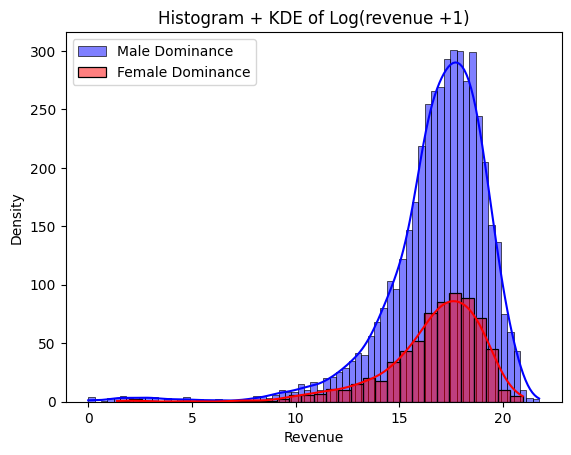

In [120]:
sns.histplot(np.log(merged_dfq8[merged_dfq8['fem_dom']==0]['revenue']),
             label='Male Dominance',color='blue',kde=True)
sns.histplot(np.log(merged_dfq8[merged_dfq8['fem_dom']==1]['revenue']),
             label='Female Dominance',color='red',kde=True)
plt.title('Histogram + KDE of Log(revenue +1)')
plt.legend()
plt.xlabel('Revenue')
plt.ylabel('Density')

plt.show()

Text(0.5, 1.0, 'Violin Plot of Revenue')

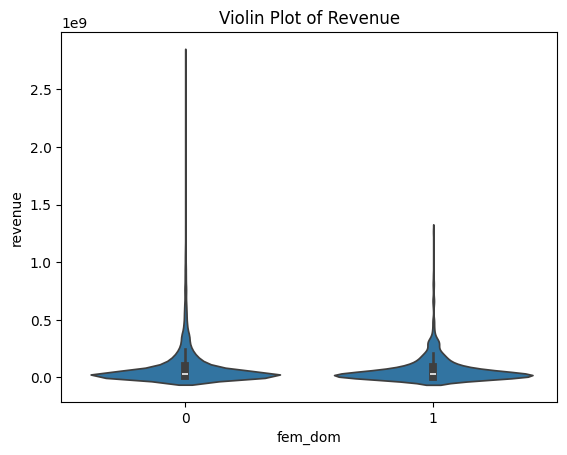

In [121]:
sns.violinplot(data=merged_dfq8, x='fem_dom', y='revenue',)
plt.title('Violin Plot of Revenue')

Text(0.5, 1.0, 'Boxplot of Budgets by Gender')

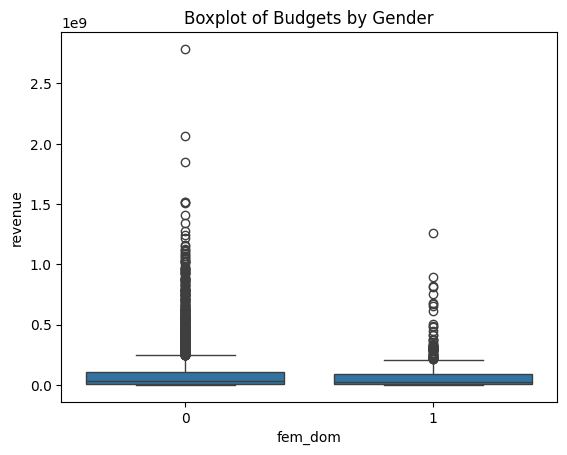

In [122]:
sns.boxplot(data=merged_dfq8, x='fem_dom', y='revenue')
plt.title('Boxplot of Budgets by Gender')

Μελετώντας τα παραπάνω γραφήματα και κυρίως το boxplot, μπορούμε να δούμε πως η μέση τιμή των δύο περιπτώσεων είναι περίπου ίδια, ενώ στις ταινίες που δεν έχουμε παραπάνω γυναίκες από άντρες στο cast, υπάρχουν πολλά περισσότερα outliers.  
Θα προχωρήσουμε τώρα στην στατιστική ανάλυση. Θα ξεκινήσουμε με το t-test.  
Έχουμε ως null Hypothesis (H0) την υπόθεση: Έστω ότι οι ταινίες με περισσότερες γυναίκες από άντρες στο cast έχουμε το μεγαλύτερο ή ίσο revenue με ταινίες με περισσότερους άντρες.

In [123]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(merged_dfq8[merged_dfq8['fem_dom']==1]['revenue'],merged_dfq8[merged_dfq8['fem_dom']==0]['revenue'],alternative='less',equal_var=False)
print("t_stat = ",t_stat)
print("p_value = ", p_value)

t_stat =  -4.282408719298534
p_value =  9.981078184955953e-06


Βλέπουμε πως p_value < 0.05 οπότε μπορούμε να απορρίψουμε την null υπόθεση (Η0).  
Άρα με βάση την t-student ισχύει η υπόθεση ότι  οι ταινίες με περισσότερες γυναίκες από άντρες στο cast έχουν χαμηλότερο revenue. Θα συνεχίσουμε με την μέθοδο kolmogorov.

In [124]:
ks_stat, p_value = stats.ks_2samp(merged_dfq8[merged_dfq8['fem_dom']==1]['revenue'],merged_dfq8[merged_dfq8['fem_dom']==0]['revenue'], alternative='left-sided')

print("ks_stat = ", ks_stat)
print("p_value = ", p_value)

ks_stat =  0.006677212269243399
p_value =  0.9420392534206528


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Στην συγκεκριμένη μέθοδο βλέπουμε πως p_value > 0.05, οπότε δεν μπορούμε να πούμε πως οι ταινίες με περισσότερες γυναίκες από άντρες στο cast έχουν χαμηλότερο revenue.